## <center> From Data to Dollars - Predicting Insurance Charges <center>

In [203]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [204]:
# Load the insurance dataset
df = pd.read_csv("datasets/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [205]:
# Info of data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1272 non-null   float64
 1   sex       1272 non-null   object 
 2   bmi       1272 non-null   float64
 3   children  1272 non-null   float64
 4   smoker    1272 non-null   object 
 5   region    1272 non-null   object 
 6   charges   1284 non-null   object 
dtypes: float64(3), object(4)
memory usage: 73.3+ KB


In [206]:
# Check for missing values
print("Missing values per column in the data frame:\n ", df.isna().sum())

Missing values per column in the data frame:
  age         66
sex         66
bmi         66
children    66
smoker      66
region      66
charges     54
dtype: int64


In [207]:
# Check for duplicates
df.duplicated().sum().sum()

1

In [208]:
# Unique values of each column
for i in df.columns:
    print(i,":\n",df[i].unique())

age :
 [ 19.  18.  28.  33.  32. -31.  46.  37.  60.  25.  62.  23.  56. -27.
  52. -23.  30. -34.  59.  63.  55.  31.  22.  nan  26.  35.  24.  41.
  21.  48.  36.  40.  58.  34.  43.  64.  20.  61.  27.  53.  44.  57.
 -41.  45. -35.  54.  38.  29.  49.  47.  51.  42.  50. -44. -39. -28.
 -40.  39. -25. -52. -26. -47. -45. -57. -43. -50. -58. -56. -30. -51.
 -60. -37. -55. -64. -22. -36. -21. -18. -20. -19. -33.]
sex :
 ['female' 'male' 'woman' 'F' 'man' nan 'M']
bmi :
 [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1      nan 28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  37.3   38.665 34.77  24.53  35.625 28.    34.43
 28.69  36.955 31.825 31.68  22.88  37.335 27.36  33.66  24.7   25.935
 22.42  28.9   39.1   36.19  23.98  24.75  28.5   28.1   32.01  27.4
 34.01  35.53  39.805 26.885 38.285 

In [209]:
# Age column
# Remove negative signs by finding absolute values
df["age"] = np.abs(df["age"])
df["age"].unique()

array([19., 18., 28., 33., 32., 31., 46., 37., 60., 25., 62., 23., 56.,
       27., 52., 30., 34., 59., 63., 55., 22., nan, 26., 35., 24., 41.,
       21., 48., 36., 40., 58., 43., 64., 20., 61., 53., 44., 57., 45.,
       54., 38., 29., 49., 47., 51., 42., 50., 39.])

In [210]:
# Sex column
# Recategorize values to 'female' and 'male'
cat = {"female": "female", "male": "male", "woman": "female", "F": "female", "man": "male", "M": "male"}
df["sex"] = df["sex"].map(cat)
df["sex"].unique()

array(['female', 'male', nan], dtype=object)

In [211]:
# Children column
# Remove negative signs by finding absolute values
df["children"] = np.abs(df["children"])
df["children"].unique()

array([ 0.,  1.,  3.,  2., nan,  4.,  5.])

In [212]:
# Region column
# Recategorize values to 'southeast', 'southwest', 'northeast', 'northwest'
regions = {"southwest": "southwest", "Southeast": "southeast", "southeast": "southeast", "northwest": "northwest",
           "Northwest": "northwest", "Northeast": "northeast", "northeast": "northeast", "Southwest": "southwest"}
df["region"] = df["region"].map(regions)
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast', nan],
      dtype=object)

In [213]:
# Remove '$' from the 'charges' column
df["charges"] = df["charges"].str.replace("$", "")
df["charges"].unique()


array(['16884.924', '1725.5523', '4449.462', ..., '1629.8335', '2007.945',
       '29141.3603'], dtype=object)

Text(0.5, 1.0, 'Distribution of Age')

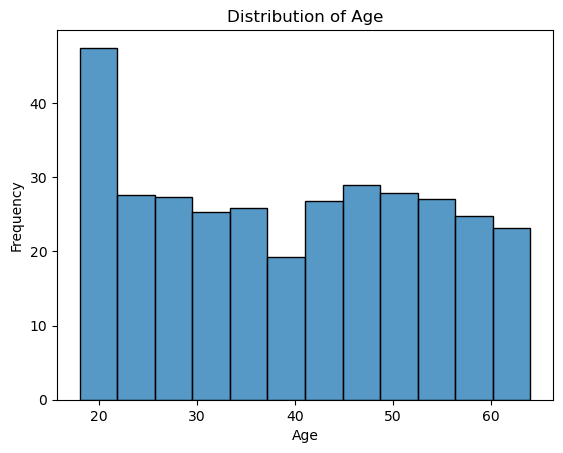

In [214]:
# Distribution for 'age' column
sns.histplot(data = df, x = 'age', stat = 'frequency')
plt.xlabel("Age")
plt.title("Distribution of Age")

In [215]:
# Statistics of 'age'
df["age"].describe()

count    1272.000000
mean       39.335692
std        14.064247
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

The demography in this dataset are mostly in their 20s
* Overall, a uniform distribution

In [216]:
# Value count of 'sex'
df["sex"].value_counts()

sex
male      645
female    627
Name: count, dtype: int64

Text(0.5, 1.0, 'Count of Female vs Male')

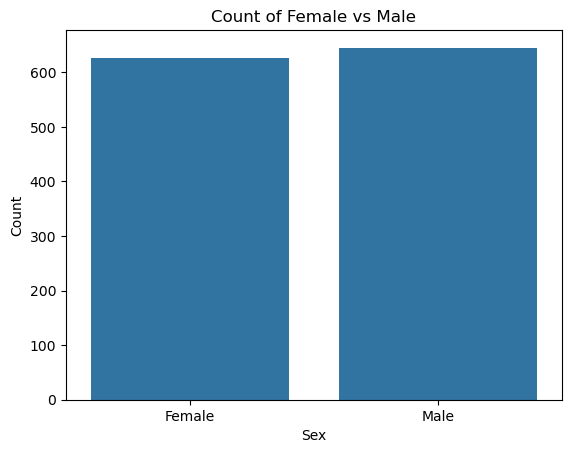

In [217]:
# Distribution for 'sex'
sns.countplot(data = df, x = 'sex')
plt.xticks([0,1], ["Female", "Male"])
plt.ylabel("Count")
plt.xlabel("Sex")
plt.title("Count of Female vs Male")

There are more males than females in this dataset
* Only a slight higher count of males than females

In [218]:
# Statistics of 'bmi'
df["bmi"].describe()


count    1272.000000
mean       30.560550
std         6.095573
min        15.960000
25%        26.180000
50%        30.210000
75%        34.485000
max        53.130000
Name: bmi, dtype: float64

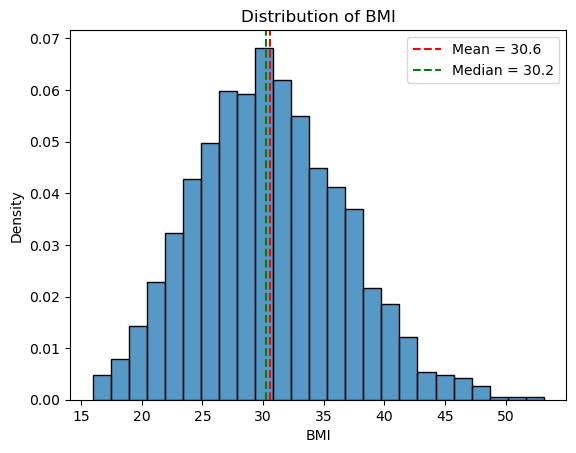

In [219]:
# Distribution of 'bmi'
sns.histplot(data = df, x = 'bmi', stat = 'density')
plt.xlabel('BMI')
plt.title('Distribution of BMI')
plt.axvline(30.6, color = 'red', linestyle = '--', label = 'Mean = 30.6')
plt.axvline(30.2, color = 'green', linestyle = '--', label = 'Median = 30.2')
plt.legend()

Most of the demography have the BMI of 30
* The mean and median are almost equal
* The distribution of BMI resembles a normal distribution

Text(0.5, 1.0, 'Count of Children')

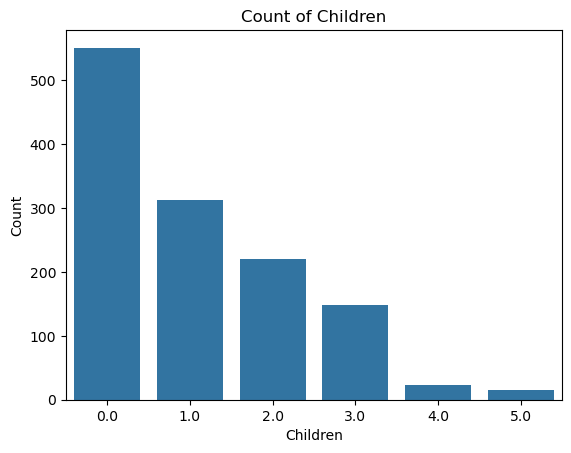

In [220]:
# Countplot of 'children'
sns.countplot(data = df, x = 'children')
plt.xlabel('Children')
plt.ylabel('Count')
plt.title('Count of Children')

Most people don't have children

In [221]:
# Value counts of 'smoker'
df["smoker"].value_counts()

smoker
no     1013
yes     259
Name: count, dtype: int64

Text(0, 0.5, 'Count')

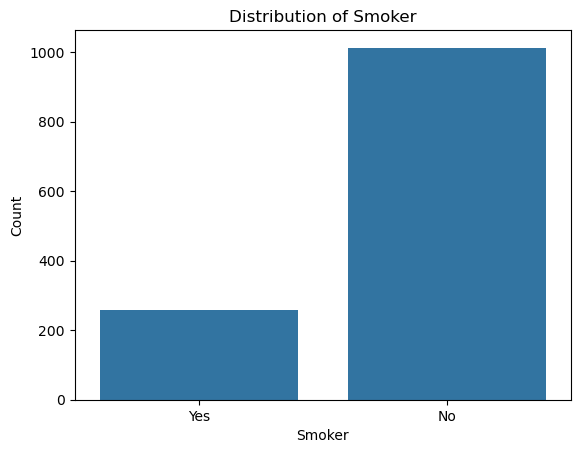

In [222]:
# Count of 'smoker'
sns.countplot(data = df, x = 'smoker')
plt.title('Distribution of Smoker')
plt.xticks([0,1], ['Yes', 'No'])
plt.xlabel('Smoker')
plt.ylabel('Count')


There is an overwhelming amount of non-smokers in the dataset compared to smokers

In [223]:
# Value counts of 'region'
df["region"].value_counts()

region
southeast    342
southwest    312
northwest    310
northeast    308
Name: count, dtype: int64

Text(0, 0.5, 'Count')

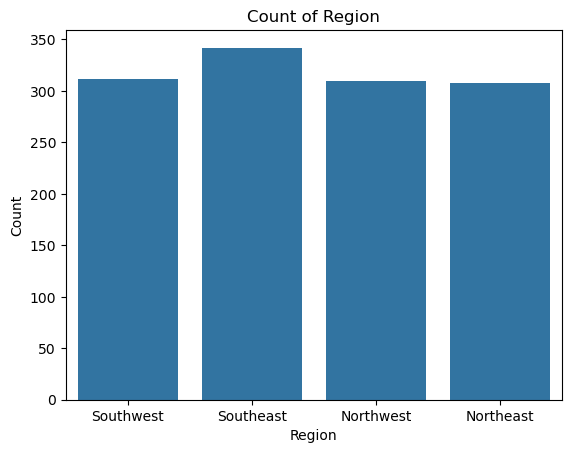

In [224]:
# Count of 'region'
sns.countplot(data = df, x = 'region')
plt.title("Count of Region")
plt.xticks([0,1,2,3], ['Southwest', 'Southeast', 'Northwest', 'Northeast'])
plt.xlabel('Region')
plt.ylabel('Count')

The regions are equally distributed
* 'Southeast' has slightly more people than the other regions

In [225]:
# Divide 'charges' by 1000
charges_thousands = df["charges"].astype('float')
charges_thousands = charges_thousands / 1000
charges_thousands

0       16.884924
1        1.725552
2        4.449462
3       21.984471
4        3.866855
          ...    
1333    10.600548
1334     2.205981
1335     1.629833
1336     2.007945
1337    29.141360
Name: charges, Length: 1338, dtype: float64

In [226]:
# Statistics of charges (scale = 1000)
charges_thousands.describe()

count    1272.000000
mean       13.286594
std        12.142505
min         1.121874
25%         4.733582
50%         9.382033
75%        16.579959
max        63.770428
Name: charges, dtype: float64

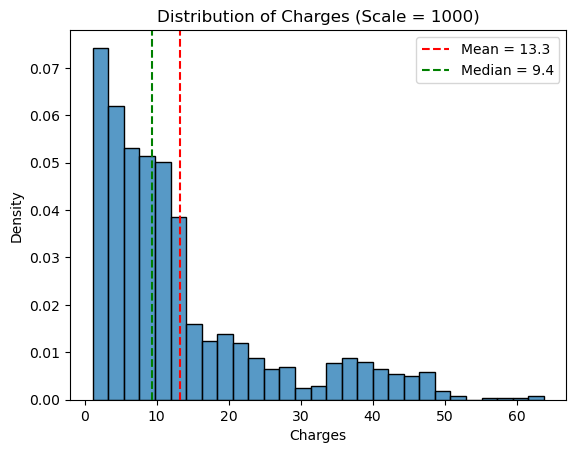

In [227]:
# Distribution of 'charges'
sns.histplot(charges_thousands, stat = 'density')
plt.title('Distribution of Charges (Scale = 1000)')
plt.xlabel('Charges')
plt.axvline(13.3, linestyle = '--', color = 'red', label = 'Mean = 13.3')
plt.axvline(9.4, linestyle = '--', color = 'green', label = 'Median = 9.4')
plt.legend()

Most charges are under $15,000
* Data are skewed right
* Mean charge is about $13,000 and the median charge is $9,000
* There are outliers in the data

In [228]:
# Check for missing values
df.isna().sum()

age         66
sex         66
bmi         66
children    66
smoker      66
region      66
charges     54
dtype: int64

In [229]:
# Check the shape of the data frame
df.shape

(1338, 7)

There are 1338 rows in total. The maximum number of missing values is 66 (1 row of data may have more than 1 missing values)
* (66/1338) * 100  is about 4.9% ~ 5%
* We must impute data

In [230]:
# Fill 'NA' in 'bmi' with 'median' method
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
bmi_imputed = imputer.fit_transform(df[["bmi"]])
df["bmi"] = bmi_imputed

In [231]:
# Fill 'NA' in 'charges' with 'median' method
charges_imputed = imputer.fit_transform(df[["charges"]])
df["charges"] = charges_imputed

In [232]:
# Fill 'NA' in 'age' with 'median' method
age_imputed = imputer.fit_transform(df[["age"]])
df["age"] = age_imputed

In [233]:
# Fill 'NA' in 'children' with 'median' method
children_imputed = imputer.fit_transform(df[["children"]])
df["children"] = children_imputed

In [234]:
# Fill 'NA' in 'sex' with 'most_frequent' method
cat_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
sex_imputed = cat_imputer.fit_transform(df[["sex"]])
sex_imputed = pd.DataFrame(sex_imputed, columns = ["sex"])
df["sex"] = sex_imputed["sex"]


In [235]:
# Fill 'NA' in 'smoker' with with 'most_frequent' method
smoker_imputed = cat_imputer.fit_transform(df[["smoker"]])
smoker_imputed = pd.DataFrame(smoker_imputed, columns = ["smoker"])
df["smoker"] = smoker_imputed["smoker"]

In [236]:
# Fill 'NA' in 'region' with 'most_frequent' method
region_imputed = cat_imputer.fit_transform(df[["region"]])
region_imputed = pd.DataFrame(region_imputed, columns = ["region"])
df["region"] = region_imputed["region"]

In [237]:
# Check for missing values
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [238]:
# Check for outliers in the 'charges' column
q1 = np.quantile(df["charges"], 0.25)
q3 = np.quantile(df["charges"], 0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

lower_bound_counter = 0
upper_bound_counter = 0
for index, value in df["charges"].items():
    if value < lower_bound:
        lower_bound_counter += 1
    elif value > upper_bound:
        upper_bound_counter += 1
    else:
        pass

print("Determine outliers:")
print(f"The lower_bound for 'charges' is {lower_bound} and the upper_bound for 'charges' is {upper_bound}")
print(f"There are {lower_bound_counter} values less than {lower_bound}")
print(f"There are {upper_bound_counter} values greater than {upper_bound}")

Determine outliers:
The lower_bound for 'charges' is -10510.143743749999 and the upper_bound for 'charges' is 30650.50270625
There are 0 values less than -10510.143743749999
There are 151 values greater than 30650.50270625


In [239]:
# Winsorize values greater than the upper_bound
# For values greater than the upper_bound value, set them equal to the upper_bound value
for index, value in df["charges"].items():
    if value > 30650.50270625:
        df.loc[index, "charges"] = 30650.50270625
    else:
        pass

In [240]:
# Check for values greater than the upper_bound value
counter = 0 
for index, value in df["charges"].items():
    if value > 30650.50270625:
        counter += 1
print(f"There are {counter} values greater than the upper_bound value")

There are 0 values greater than the upper_bound value


Text(0.5, 0, 'Charges')

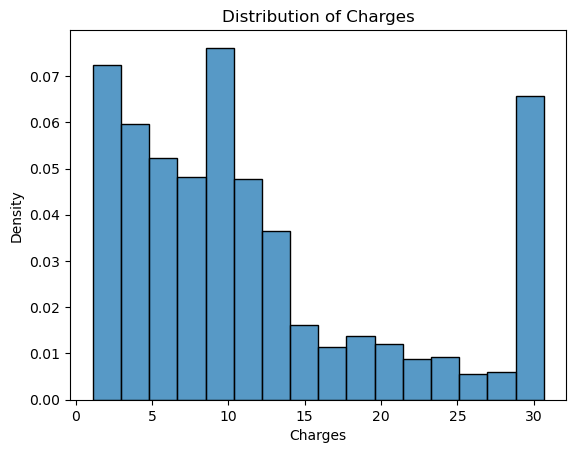

In [241]:
# Visualize the distribution of 'charges' 
charges_thousands = df["charges"] / 1000
sns.histplot(charges_thousands, stat = "density")
plt.title("Distribution of Charges")
plt.xlabel("Charges")

In [242]:
# OneHotEncoding the dataset
encoder = OneHotEncoder(handle_unknown='ignore')
categorical_features = ['sex', 'smoker', 'region']
ct = ColumnTransformer([('', encoder, categorical_features)], remainder='passthrough')
encoded_data = ct.fit_transform(df)
encoded_df = pd.DataFrame(encoded_data, columns = ct.get_feature_names_out())

encoded_df.head()

,__sex_female,__sex_male,__smoker_no,__smoker_yes,__region_northeast,__region_northwest,__region_southeast,__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__charges
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520


In [243]:
# Standard Scaling the encoded dataframe
scaler = StandardScaler()
df_scaled = scaler.fit_transform(encoded_df)
df_scaled = pd.DataFrame(df_scaled, columns = encoded_df.columns)
df_scaled.head()

,__sex_female,__sex_male,__smoker_no,__smoker_yes,__region_northeast,__region_northwest,__region_southeast,__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__charges
0,1.064881,-1.064881,-2.041084,2.041084,-0.546836,-0.549142,-0.662352,1.813412,-1.482306,-0.444882,-0.921286,0.549529
1,-0.939072,0.939072,0.489936,-0.489936,-0.546836,-0.549142,1.509772,-0.551447,-1.555257,0.543087,-0.064663,-1.127434
2,-0.939072,0.939072,0.489936,-0.489936,-0.546836,-0.549142,1.509772,-0.551447,-0.825745,0.413490,1.648584,-0.826109
3,-0.939072,0.939072,0.489936,-0.489936,-0.546836,1.821024,-0.662352,-0.551447,-0.460989,-1.319243,-0.921286,1.113653
4,-0.939072,0.939072,0.489936,-0.489936,-0.546836,1.821024,-0.662352,-0.551447,-0.533940,-0.279940,-0.921286,-0.890559


In [ ]:
# Split dataframe into train and evaluation sets
X = df_scaled.iloc[:, 0:11]
y = df_scaled.iloc[:, 11:12]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Initalize the LinearRegression model
